# Bayesian Hierarchical Modelling of Microcredit Experiments
### Complete analysis

Everything from data import to conclusion.

Method follows Gelman et al. (2013): hierarchical models from Chapter 5,
computation from Chapters 11 and 12, predictive checking from Chapter 6, model
comparison from Chapter 7, model expansion from Section 7.5.



# Part 1 — Setup

In [ ]:
!pip install -q "pymc>=5.10" arviz

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pymc as pm, arviz as az, pytensor.tensor as pt
import warnings, json, os, time, gc, sys
warnings.filterwarnings("ignore")
az.style.use("arviz-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200,
                     "savefig.bbox": "tight", "font.size": 9})
os.makedirs("figures", exist_ok=True)

SEED = 1
DRAWS, TUNE, CHAINS = 1000, 2000, 2
RUN_PART_15 = False
MODELS_TO_FIT = ['M0 complete pooling', 'M1 no pooling', 'M2 hier tau only', 'M3 hier both', 'M5 hier + sigma']
LL_THIN  = 8     # thinning for the log-likelihood, keeps 500 draws
PPC_DRAW = 150

FITS, LOOD, RESULT = {}, {}, {}
BLUE, RED, GREY, PURPLE = "#2B5D9B", "#B03A2E", "#8A8A8A", "#7B4FA8"
q = lambda x: np.percentile(x, [2.5, 97.5])

print("PyMC", pm.__version__, "| ArviZ", az.__version__)

PyMC 5.28.5 | ArviZ 0.22.0


# Part 2 — Data import and preparation



In [ ]:
from google.colab import files
up = files.upload()

df = pd.read_csv([f for f in up if f.endswith('.csv')][0])
SITES = ["Mexico","Mongolia","Bosnia","India","Morocco","Philippines","Ethiopia"]
K = len(SITES)

if "site_idx" not in df.columns:
    df["site_idx"] = pd.Categorical(df["site"], categories=SITES).codes
df["site_idx"] = df["site_idx"].astype(int)
df["treat"]    = df["treat"].astype(int)
df["site"]     = [SITES[i] for i in df.site_idx]

n_before = len(df)
df = df[["site","site_idx","treat","y"]].dropna().reset_index(drop=True)
assert df.site_idx.nunique() == K,      "expected seven sites"
assert set(df.treat.unique()) == {0,1}, "treat must be 0 or 1"
assert len(df) == n_before,             "unexpected missing values"

idx   = df.site_idx.to_numpy()
treat = df.treat.to_numpy().astype(float)
y     = df.y.to_numpy()
N     = len(y)

print(f"{N:,} households across {K} sites, no missing values")
df.head()

Saving microcredit_profit.csv to microcredit_profit.csv
35,303 households across 7 sites, no missing values


,site,site_idx,treat,y
0,Mexico,0,0,0.000000
1,Mexico,0,1,513.246492
2,Mexico,0,1,0.000000
3,Mexico,0,0,0.000000
4,Mexico,0,0,0.000000


# Part 3 — Exploratory analysis


In [ ]:
rows = []
for j, s in enumerate(SITES):
    g  = df[df.site_idx == j]
    yc = g.loc[g.treat==0,"y"].to_numpy(); yt = g.loc[g.treat==1,"y"].to_numpy()
    n0, n1 = len(yc), len(yt)
    s2 = ((n1-1)*yt.var(ddof=1) + (n0-1)*yc.var(ddof=1))/(n1+n0-2)
    gy = g.y.to_numpy(); nz = gy[gy != 0]
    rows.append({"site": s, "N": n0+n1, "treated": n1, "control": n0,
                 "control mean": yc.mean(), "difference": yt.mean()-yc.mean(),
                 "std error": np.sqrt(s2*(1/n1+1/n0)), "within SD": np.sqrt(s2),
                 "neg %": 100*(gy<0).mean(), "zero %": 100*(gy==0).mean(),
                 "pos %": 100*(gy>0).mean(),
                 "mean if active": nz.mean(), "SD if active": nz.std()})
desc = pd.DataFrame(rows).set_index("site")

n_neg, n_zero, n_pos = int((y<0).sum()), int((y==0).sum()), int((y>0).sum())
skew = float(((y-y.mean())**3).mean()/y.std()**3)
kurt = float(((y-y.mean())**4).mean()/y.var()**2)

print(f"POOLED   N={N:,}   mean={y.mean():.2f}   SD={y.std():.1f}   median={np.median(y):.1f}")
print(f"         coefficient of variation = {y.std()/y.mean():.1f}\n")
print("The outcome has three distinct parts, not two:")
print(f"   negative  {n_neg:6,}  ({100*n_neg/N:5.1f}%)   businesses making a loss, down to {y.min():,.0f}")
print(f"   zero      {n_zero:6,}  ({100*n_zero/N:5.1f}%)   exactly zero, a genuine point mass")
print(f"   positive  {n_pos:6,}  ({100*n_pos/N:5.1f}%)   up to {y.max():,.0f}\n")
print(f"skewness = {skew:.2f}, so the heavy tail is on the LEFT: the extreme values")
print(f"are large losses, not large profits.")
print(f"kurtosis = {kurt:.0f}, against 3 for a normal.\n")
print(f"within-site SD  {desc['within SD'].min():8.2f} to {desc['within SD'].max():9.2f}"
      f"   (factor of {desc['within SD'].max()/desc['within SD'].min():.0f})")
print(f"std error       {desc['std error'].min():8.2f} to {desc['std error'].max():9.2f}"
      f"   (factor of {desc['std error'].max()/desc['std error'].min():.0f})")
print(f"raw estimate    {desc['difference'].min():8.2f} to {desc['difference'].max():9.2f}")
print(f"share at zero   {desc['zero %'].min():8.1f}% to {desc['zero %'].max():8.1f}%\n")
print("Four features that shape every modelling choice below:")
print("  a majority of outcomes are exactly zero, which no continuous density can match")
print("  a tenth are negative, so the outcome cannot be logged and is not a count")
print("  the sites differ enormously in precision, so pooling will act unevenly")
print("  the tails are heavy and left leaning, so the normal likelihood is an assumption\n")

RESULT["data"] = {"n": int(N), "mean": float(y.mean()), "sd": float(y.std()),
                  "n_negative": n_neg, "n_zero": n_zero, "n_positive": n_pos,
                  "pct_zero": float(100*n_zero/N), "skewness": skew, "kurtosis": kurt,
                  "per_site": desc.round(3).to_dict("index")}
desc.round(2)

POOLED   N=35,303   mean=46.18   SD=435.5   median=0.0
         coefficient of variation = 9.4

The outcome has three distinct parts, not two:
   negative   3,493  (  9.9%)   businesses making a loss, down to -40,854
   zero      21,928  ( 62.1%)   exactly zero, a genuine point mass
   positive   9,882  ( 28.0%)   up to 20,173

skewness = -12.96, so the heavy tail is on the LEFT: the extreme values
are large losses, not large profits.
kurtosis = 2699, against 3 for a normal.

within-site SD      3.07 to   1039.75   (factor of 339)
std error           0.22 to     78.13   (factor of 351)
raw estimate       -4.55 to     66.56
share at zero       10.6% to     82.7%

Four features that shape every modelling choice below:
  a majority of outcomes are exactly zero, which no continuous density can match
  a tenth are negative, so the outcome cannot be logged and is not a count
  the sites differ enormously in precision, so pooling will act unevenly
  the tails are heavy and left leaning, so th

,N,treated,control,control mean,difference,std error,within SD,neg %,zero %,pos %,mean if active,SD if active
site,,,,,,,,,,,,
Mexico,16560,8262,8298,14.38,-4.55,5.88,378.26,4.19,82.72,13.09,70.06,907.62
Mongolia,961,701,260,-0.68,-0.34,0.22,3.07,17.59,77.63,4.79,-4.14,5.37
Bosnia,1195,627,568,97.34,37.53,19.78,341.48,0.00,72.55,27.45,426.40,541.74
India,6863,3599,3264,29.37,16.72,11.83,489.43,4.66,74.63,20.71,150.36,963.02
Morocco,5498,2720,2778,81.05,17.54,11.40,422.67,27.59,18.48,53.93,110.07,465.75
Philippines,1113,892,221,381.35,66.56,78.13,1039.75,0.90,13.39,85.71,501.89,1101.38
Ethiopia,3113,1586,1527,13.00,7.29,7.89,220.16,25.15,10.60,64.25,18.70,232.72


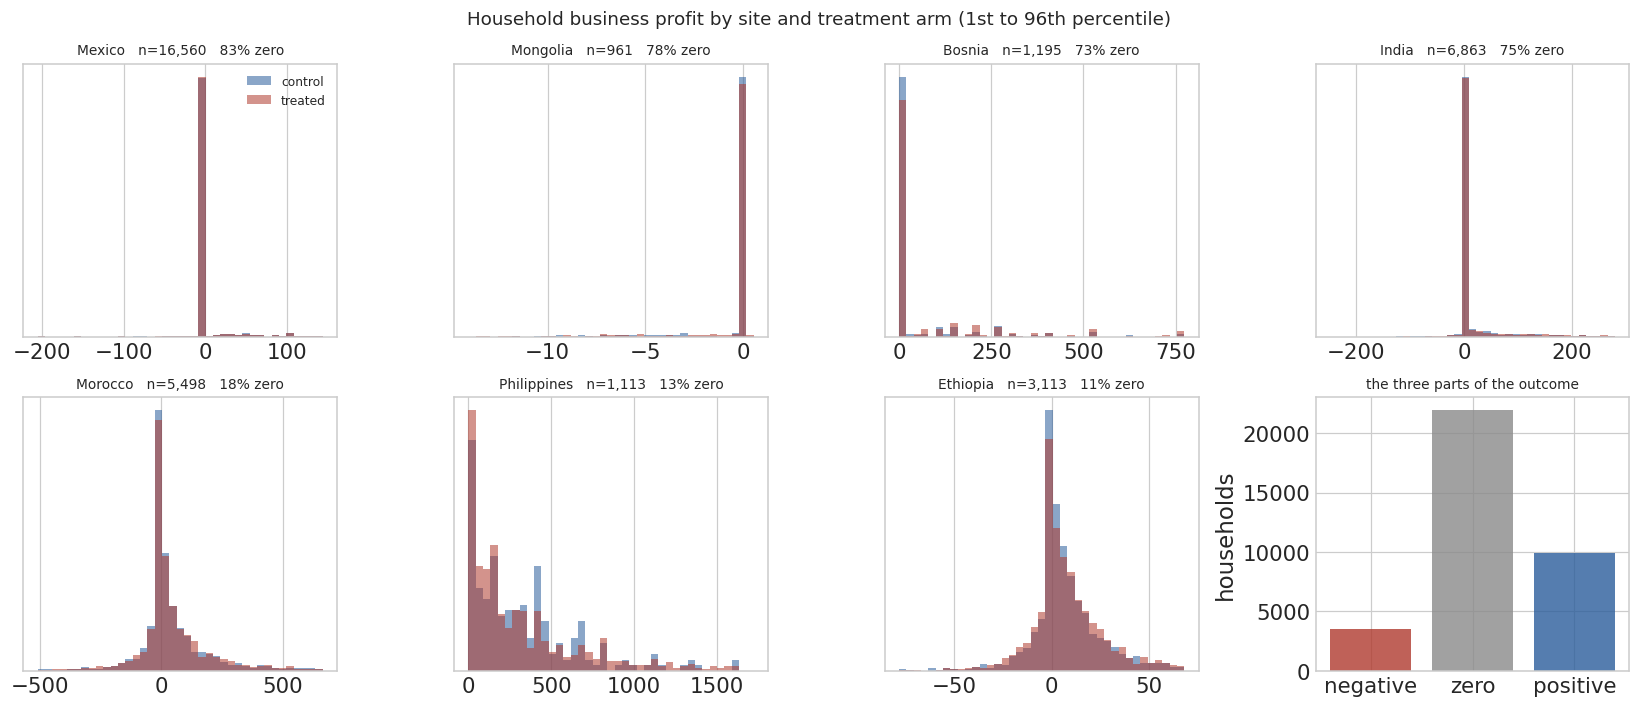

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6.5))
for j, s in enumerate(SITES):
    ax = axes.flat[j]; g = df[df.site_idx == j]
    lo, hi = np.percentile(g.y, [1, 96]); bins = np.linspace(lo, max(hi, lo+1), 40)
    for t, lab, c in ((0,"control",BLUE), (1,"treated",RED)):
        ax.hist(g.loc[g.treat==t,"y"], bins=bins, density=True, alpha=.55, label=lab, color=c)
    ax.set_title(f"{s}   n={len(g):,}   {100*(g.y==0).mean():.0f}% zero", fontsize=9)
    ax.set_yticks([])
    if j == 0: ax.legend(fontsize=8)
ax = axes.flat[7]
ax.bar(["negative","zero","positive"], [n_neg, n_zero, n_pos],
       color=[RED, GREY, BLUE], alpha=.8)
ax.set_title("the three parts of the outcome", fontsize=9)
ax.set_ylabel("households")
fig.suptitle("Household business profit by site and treatment arm (1st to 96th percentile)",
             fontsize=12)
plt.tight_layout(); plt.savefig("figures/01_data.png"); plt.show()

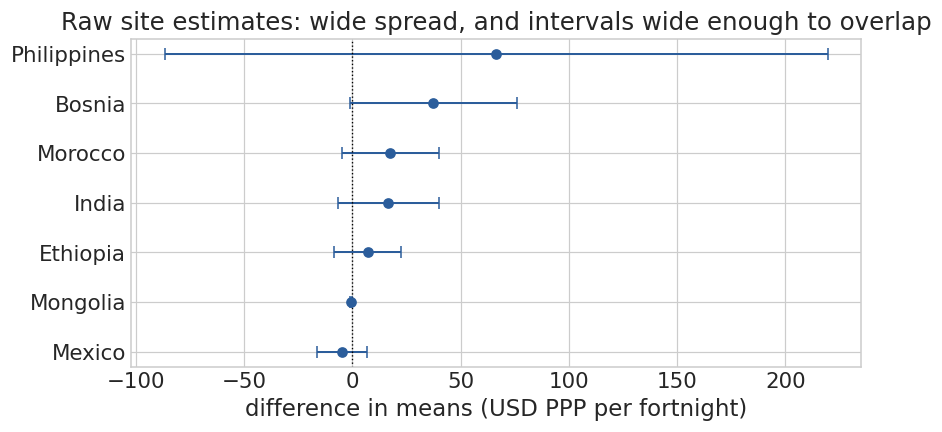

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
o = np.argsort(desc["difference"].values)
ax.errorbar(desc["difference"].values[o], np.arange(K),
            xerr=1.96*desc["std error"].values[o], fmt="o", color=BLUE,
            capsize=4, ms=6, lw=1.3)
ax.axvline(0, color="k", ls=":", lw=.9)
ax.set_yticks(range(K)); ax.set_yticklabels(desc.index[o])
ax.set_xlabel("difference in means (USD PPP per fortnight)")
ax.set_title("Raw site estimates: wide spread, and intervals wide enough to overlap")
plt.tight_layout(); plt.savefig("figures/02_raw_estimates.png"); plt.show()

# Part 4 — Data verification



In [ ]:
PUBLISHED_SD = [378.27, 3.08, 342.13, 489.49, 422.74, 1041.14, 220.16]
ver = pd.DataFrame({"published": PUBLISHED_SD,
                    "computed": desc["within SD"].values}, index=SITES)
ver["difference %"] = 100*(ver.computed - ver.published).abs()/ver.published

RESULT["verification"] = {"max_error_pct": float(ver["difference %"].max()),
                          "table": ver.round(4).to_dict("index")}
print(f"maximum deviation: {ver['difference %'].max():.2f}%\n")
print("Small residual differences are expected rather than worrying: the published")
print("values are posterior means from a model that estimates these jointly, while")
print("the computed column is a plain sample standard deviation.\n")
ver.round(2)

maximum deviation: 0.34%

Small residual differences are expected rather than worrying: the published
values are posterior means from a model that estimates these jointly, while
the computed column is a plain sample standard deviation.



,published,computed,difference %
Mexico,378.27,378.26,0.00
Mongolia,3.08,3.07,0.34
Bosnia,342.13,341.48,0.19
India,489.49,489.43,0.01
Morocco,422.74,422.67,0.02
Philippines,1041.14,1039.75,0.13
Ethiopia,220.16,220.16,0.00


# Part 5 — Model specifications

In [ ]:
S0  = np.full(K, 300.0)
MU0 = np.full(K, 50.)
TA0 = np.full(K, 5.)

def M0():
    """complete pooling: one shared treatment effect"""
    with pm.Model(coords={"site":SITES}) as m:
        mu_k = pm.Normal("mu_k", 0, 1000, dims="site", initval=MU0)
        tau  = pm.Normal("tau", 0, 1000, initval=5.)
        sk   = pm.HalfNormal("sigma_k", 1000, dims="site", initval=S0)
        pm.Normal("y", mu_k[idx] + tau*treat, sk[idx], observed=y)
    return m

def M1():
    """no pooling: each site estimated alone"""
    with pm.Model(coords={"site":SITES}) as m:
        mu_k  = pm.Normal("mu_k", 0, 1000, dims="site", initval=MU0)
        tau_k = pm.Normal("tau_k", 0, 1000, dims="site", initval=TA0)
        sk    = pm.HalfNormal("sigma_k", 1000, dims="site", initval=S0)
        pm.Normal("y", mu_k[idx] + tau_k[idx]*treat, sk[idx], observed=y)
    return m

def M2():
    """hierarchical on the treatment effects only"""
    with pm.Model(coords={"site":SITES}) as m:
        mu_k = pm.Normal("mu_k", 0, 1000, dims="site", initval=MU0)
        tau  = pm.Normal("tau", 0, 1000, initval=5.)
        st   = pm.HalfNormal("sigma_tau", 50, initval=10.)
        tau_k= pm.Normal("tau_k", tau, st, dims="site", initval=TA0)
        sk   = pm.HalfNormal("sigma_k", 1000, dims="site", initval=S0)
        pm.Normal("y", mu_k[idx] + tau_k[idx]*treat, sk[idx], observed=y)
        pm.Normal("tau_new", tau, st)
    return m

def M3():
    """hierarchical on baselines and effects -- main specification"""
    with pm.Model(coords={"site":SITES}) as m:
        mu = pm.Normal("mu", 0, 1000, initval=50.)
        tau= pm.Normal("tau", 0, 1000, initval=5.)
        sm = pm.HalfNormal("sigma_mu", 500, initval=100.)
        st = pm.HalfNormal("sigma_tau", 50, initval=10.)
        mu_k  = pm.Normal("mu_k",  mu,  sm, dims="site", initval=MU0)
        tau_k = pm.Normal("tau_k", tau, st, dims="site", initval=TA0)
        sk = pm.HalfNormal("sigma_k", 1000, dims="site", initval=S0)
        pm.Normal("y", mu_k[idx] + tau_k[idx]*treat, sk[idx], observed=y)
        pm.Normal("tau_new", tau, st)
    return m

def M4():
    """baselines and effects correlated across sites (Meager's joint model)"""
    with pm.Model(coords={"site":SITES}) as m:
        mu = pm.Normal("mu", 0, 1000, initval=50.)
        tau= pm.Normal("tau", 0, 1000, initval=5.)
        chol, corr, stds = pm.LKJCholeskyCov(
            "chol", n=2, eta=2,
            sd_dist=pm.HalfNormal.dist(sigma=np.array([500., 50.]), shape=2),
            compute_corr=True)
        theta = pm.MvNormal("theta_k", mu=pt.stack([mu, tau]), chol=chol,
                            shape=(K, 2), initval=np.column_stack([MU0, TA0]))
        mu_k  = pm.Deterministic("mu_k",  theta[:,0], dims="site")
        tau_k = pm.Deterministic("tau_k", theta[:,1], dims="site")
        pm.Deterministic("rho", corr[0,1])
        st = pm.Deterministic("sigma_tau", stds[1])
        sk = pm.HalfNormal("sigma_k", 1000, dims="site", initval=S0)
        pm.Normal("y", mu_k[idx] + tau_k[idx]*treat, sk[idx], observed=y)
        pm.Normal("tau_new", tau, st)
    return m

def M5():
    """as M3, with the residual scales pooled on the log scale"""
    with pm.Model(coords={"site":SITES}) as m:
        mu = pm.Normal("mu", 0, 1000, initval=50.)
        tau= pm.Normal("tau", 0, 1000, initval=5.)
        sm = pm.HalfNormal("sigma_mu", 500, initval=100.)
        st = pm.HalfNormal("sigma_tau", 50, initval=10.)
        mu_k  = pm.Normal("mu_k",  mu,  sm, dims="site", initval=MU0)
        tau_k = pm.Normal("tau_k", tau, st, dims="site", initval=TA0)
        lm = pm.Normal("log_s_mu", 5, 3, initval=5.5)
        ls = pm.HalfNormal("log_s_sd", 2, initval=1.)
        log_sk = pm.Normal("log_sigma_k", lm, ls, dims="site", initval=np.log(S0))
        sk = pm.Deterministic("sigma_k", pt.exp(log_sk), dims="site")
        pm.Normal("y", mu_k[idx] + tau_k[idx]*treat, sk[idx], observed=y)
        pm.Normal("tau_new", tau, st)
    return m

def M7():
    """as M3 with the uniform priors of the supplied Stan code"""
    with pm.Model(coords={"site":SITES}) as m:
        mu = pm.Normal("mu", 0, 1000, initval=50.)
        tau= pm.Normal("tau", 0, 1000, initval=5.)
        sm = pm.Uniform("sigma_mu", 0, 1e5, initval=100.)
        st = pm.Uniform("sigma_tau", 0, 1e5, initval=10.)
        mu_k  = pm.Normal("mu_k",  mu,  sm, dims="site", initval=MU0)
        tau_k = pm.Normal("tau_k", tau, st, dims="site", initval=TA0)
        sk = pm.Uniform("sigma_k", 0, 1e5, dims="site", initval=S0)
        pm.Normal("y", mu_k[idx] + tau_k[idx]*treat, sk[idx], observed=y)
        pm.Normal("tau_new", tau, st)
    return m

BUILDERS = {"M0 complete pooling":M0, "M1 no pooling":M1, "M2 hier tau only":M2,
            "M3 hier both":M3, "M4 hier correlated":M4, "M5 hier + sigma":M5,
            "M7 uniform priors":M7}

print(f"{len(BUILDERS)} models will be fitted")

7 models will be fitted; M6 defined but deferred


# Part 6 — Fitting (this machine: five of seven models)

This notebook fits M0, M1, M2, M3 and M5. The other notebook on the
fits M4 and M7.

In [ ]:
import os
SAVE_DIR = "/content/fits"; os.makedirs(SAVE_DIR, exist_ok=True)
_p = lambda n,k: os.path.join(SAVE_DIR, f"{n.replace(' ','_')}_{k}.nc")

for name in list(BUILDERS):
    if name not in MODELS_TO_FIT: BUILDERS.pop(name)
print("this notebook fits:", ", ".join(BUILDERS), "\n")

for name, build in BUILDERS.items():
    fit_p, loo_p = _p(name,"fit"), _p(name,"loo")
    if name in FITS:
        print(f"  {name:<22} in memory, skipped"); continue
    if os.path.exists(fit_p) and os.path.exists(loo_p):
        FITS[name] = az.from_netcdf(fit_p); LOOD[name] = az.from_netcdf(loo_p)
        print(f"  {name:<22} loaded from disk"); continue

    t0 = time.time()
    ta = 0.90 if name in ("M0 complete pooling","M1 no pooling") else 0.99
    with build():
        ida = pm.sample(draws=DRAWS, tune=TUNE, chains=CHAINS, target_accept=ta,
                        random_seed=SEED, progressbar=True,
                        idata_kwargs={"log_likelihood": False})
    FITS[name] = ida
    thin = ida.isel(draw=slice(None, None, LL_THIN)).copy()
    m_ll = build()
    for rv in m_ll.rvs_to_initial_values: m_ll.rvs_to_initial_values[rv] = None
    with m_ll: pm.compute_log_likelihood(thin, progressbar=False)
    LOOD[name] = thin
    ida.to_netcdf(fit_p); thin.to_netcdf(loo_p)   # written immediately

    ss=ida.sample_stats; nd=int(ss.diverging.sum()); tot=CHAINS*DRAWS
    sat=float((ss.tree_depth.values>=10).mean()*100)
    flag = "" if nd==0 else ("  <- still diverging" if nd/tot>0.005 else "  <- a few")
    print(f"  {name:<22} {time.time()-t0:6.0f}s   ta {ta:.2f}   "
          f"divergences {nd:5d} ({100*nd/tot:4.1f}%)   depth10 {sat:4.1f}%{flag}")
    gc.collect()

print(f"\n{len(FITS)} models fitted here: {', '.join(FITS)}")

this notebook fits: M0 complete pooling, M1 no pooling, M2 hier tau only, M3 hier both, M5 hier + sigma 



Output()

  M0 complete pooling       211s   ta 0.90   divergences     0 ( 0.0%)   depth10  0.0%


Output()

  M1 no pooling             231s   ta 0.90   divergences     0 ( 0.0%)   depth10  0.0%


...

ERROR:pymc.stats.convergence:There were 3 divergences after tuning. Increase `target_accept` or reparameterize.


  M3 hier both             1405s   ta 0.99   divergences     3 ( 0.1%)   depth10  0.0%  <- a few


Output()

ERROR:pymc.stats.convergence:There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


  M5 hier + sigma          1389s   ta 0.99   divergences     1 ( 0.1%)   depth10  0.0%  <- a few

5 models fitted here: M0 complete pooling, M1 no pooling, M2 hier tau only, M3 hier both, M5 hier + sigma


# Part 6b — Import the models fitted on the second colab


In [ ]:
from google.colab import files
import zipfile, os

up = files.upload()                       # choose fits_worker.zip
zname = [f for f in up if f.endswith(".zip")][0]
os.makedirs(SAVE_DIR, exist_ok=True)
with zipfile.ZipFile(zname) as z:
    z.extractall(SAVE_DIR)

EXPECTED = ["M0 complete pooling","M1 no pooling","M2 hier tau only","M3 hier both",
            "M4 hier correlated","M5 hier + sigma","M7 uniform priors"]
for name in EXPECTED:
    if name in FITS: continue
    f, l = _p(name,"fit"), _p(name,"loo")
    if os.path.exists(f) and os.path.exists(l):
        FITS[name] = az.from_netcdf(f); LOOD[name] = az.from_netcdf(l)
        print(f"  imported {name}")

print(f"\n{len(FITS)} of {len(EXPECTED)} models now available")
missing = [m for m in EXPECTED if m not in FITS]
if missing:
    print("MISSING:", ", ".join(missing))
    print("Everything below still runs, on whatever models are present.")
else:
    print("all models present, continue to Part 7")

BUILDERS_ALL = {"M0 complete pooling":M0, "M1 no pooling":M1, "M2 hier tau only":M2,
                "M3 hier both":M3, "M4 hier correlated":M4, "M5 hier + sigma":M5,
                "M7 uniform priors":M7}
BUILDERS = {k:v for k,v in BUILDERS_ALL.items() if k in FITS}   # for the Part 8 checks

Saving fits_worker.zip to fits_worker.zip
  imported M4 hier correlated
  imported M7 uniform priors

7 of 7 models now available
all models present, continue to Part 7


# Part 7 — Criticism I: did the computation work?

Gelman et al. (2013, Sections 11.4 and 11.5), applied identically to every
model. Nothing here concerns whether a model is any good; it asks only whether
the draws can be trusted to represent its posterior. A model that fails at this
stage cannot be interpreted at all.

In [ ]:
# --------------------------------------------
def bda3_split_rhat(x):
    """x has shape (chains, draws)"""
    m, n = x.shape
    if n % 2: x = x[:, :-1]; n = x.shape[1]
    s = x.reshape(2*m, n//2); m2, n2 = s.shape       # split each chain in half
    psi_j = s.mean(axis=1); psi = psi_j.mean()
    B = n2/(m2-1) * np.sum((psi_j - psi)**2)                       # (11.2)
    W = np.mean(s.var(axis=1, ddof=1))                             # (11.3)
    if W <= 0: return np.nan
    var_plus = (n2-1)/n2 * W + B/n2                                # (11.4)
    return float(np.sqrt(var_plus/W))

def bda3_ess(x):
    """x has shape (chains, draws)"""
    m, n = x.shape
    if n % 2: x = x[:, :-1]; n = x.shape[1]
    s = x.reshape(2*m, n//2); m2, n2 = s.shape
    psi_j = s.mean(axis=1); psi = psi_j.mean()
    B = n2/(m2-1)*np.sum((psi_j-psi)**2); W = np.mean(s.var(axis=1, ddof=1))
    if W <= 0: return np.nan
    var_plus = (n2-1)/n2*W + B/n2
    rho = np.zeros(n2)
    for t in range(1, n2):
        Vt = np.mean([((c[t:] - c[:-t])**2).mean() for c in s])     # (11.7)
        rho[t] = 1 - Vt/(2*var_plus)
        # Geyer initial positive sequence: truncate at the first pair summing < 0
        if t % 2 == 0 and rho[t-1] + rho[t] < 0:
            rho[t-1] = rho[t] = 0.0; break
    return float(min(m2*n2/(1 + 2*np.sum(rho[1:])), m2*n2))         # (11.8)

def bda3_table(ida, names):
    p = ida.posterior; out = {}
    for v in names:
        if v not in p: continue
        a = p[v].values; a = a.reshape(a.shape[0], a.shape[1], -1)
        for k in range(a.shape[2]):
            key = f"{v}[{k}]" if a.shape[2] > 1 else v
            out[key] = (bda3_split_rhat(a[:,:,k]), bda3_ess(a[:,:,k]))
    return out

# check the implementation against ArviZ on the main specification
chk  = bda3_table(FITS["M3 hier both"], ["tau","sigma_tau","mu"])
az_s = az.summary(FITS["M3 hier both"], var_names=["tau","sigma_tau","mu"])
print("BDA3 formulas implemented here vs ArviZ (2021 rank-normalised form)\n")
print(f"{'parameter':<12}{'Rhat BDA3':>11}{'Rhat ArviZ':>12}{'ESS BDA3':>11}{'ESS ArviZ':>11}")
for k,(r,e) in chk.items():
    print(f"{k:<12}{r:11.4f}{az_s.loc[k,'r_hat']:12.4f}{e:11.0f}{az_s.loc[k,'ess_bulk']:11.0f}")
print("\nClose agreement. The BDA3 column is what the thesis quotes; the ArviZ")
print("column is reported alongside as the stricter modern diagnostic.")

BDA3 formulas implemented here vs ArviZ (2021 rank-normalised form)

parameter     Rhat BDA3  Rhat ArviZ   ESS BDA3  ESS ArviZ
tau              1.0011      1.0100        638        611
sigma_tau        0.9993      1.0000        333        211
mu               1.0002      1.0000       1014       1124

Close agreement. The BDA3 column is what the thesis quotes; the ArviZ
column is reported alongside as the stricter modern diagnostic.


In [ ]:
rows=[]
for name, ida in FITS.items():
    s = az.summary(ida); nd = int(ida.sample_stats.diverging.sum())
    tot = ida.posterior.sizes["chain"]*ida.posterior.sizes["draw"]
    try: bf = float(np.min(az.bfmi(ida)))
    except Exception: bf = np.nan
    b = bda3_table(ida, ["tau","sigma_tau","mu"])
    rows.append({"model":name, "divergences":nd, "div %":round(100*nd/tot,2),
                 "max R-hat":round(float(s["r_hat"].max()),4),
                 "R-hat BDA3":round(max(v[0] for v in b.values()),4) if b else np.nan,
                 "min ESS bulk":int(s["ess_bulk"].min()),
                 "min ESS tail":int(s["ess_tail"].min()),
                 "min E-BFMI":round(bf,3),
                 "passes": bool(s["r_hat"].max()<1.01 and s["ess_bulk"].min()>400 and nd==0)})
conv = pd.DataFrame(rows).set_index("model")
RESULT["convergence"] = conv.to_dict("index")
print("thresholds: R-hat < 1.01, ESS > 400, no divergences, E-BFMI > 0.3\n")
conv

thresholds: R-hat < 1.01, ESS > 400, no divergences, E-BFMI > 0.3



,divergences,div %,max R-hat,R-hat BDA3,min ESS bulk,min ESS tail,min E-BFMI,passes
model,,,,,,,,
M0 complete pooling,0,0.00,1.00,1.0001,1220,1076,1.051,True
M1 no pooling,0,0.00,1.00,NaN,2227,1144,1.068,True
M2 hier tau only,0,0.00,1.01,1.0049,285,479,0.627,False
M3 hier both,3,0.15,1.01,1.0011,211,189,0.579,False
M5 hier + sigma,1,0.05,1.01,1.0007,221,354,0.651,False
M4 hier correlated,2,0.10,1.01,1.0010,215,346,0.498,False
M7 uniform priors,16,0.80,1.00,1.0016,185,176,0.574,False


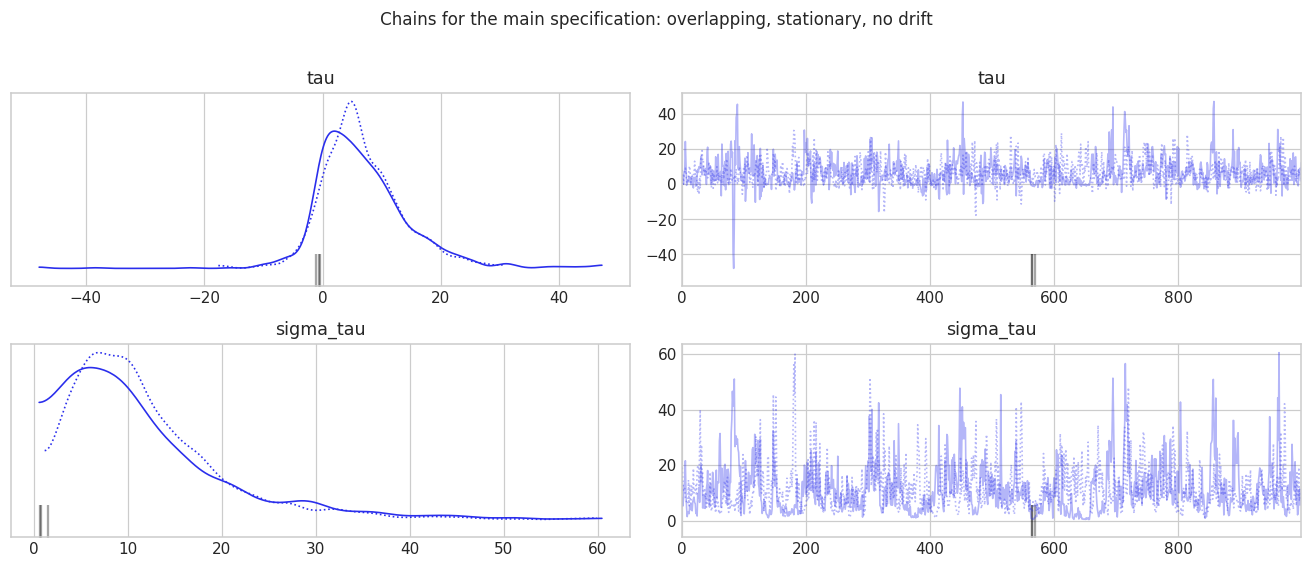

In [ ]:
az.plot_trace(FITS["M3 hier both"], var_names=["tau","sigma_tau"], figsize=(12,5))
plt.suptitle("Chains for the main specification: overlapping, stationary, no drift",
             fontsize=11, y=1.02)
plt.tight_layout(); plt.savefig("figures/03_trace.png"); plt.show()

# Part 8 — Criticism II: does the model describe the data?

Gelman et al. (2013, Chapter 6). Replicate datasets are generated from each
fitted model and compared with the data actually observed. If the model is
adequate, the real data should be unremarkable among its replicates.

In [ ]:
STATS = {
    "prop. zero": lambda v: float(np.mean(np.abs(v) < 1e-9)),
    "skewness":   lambda v: float(((v-v.mean())**3).mean()/v.std()**3),
    "kurtosis":   lambda v: float(((v-v.mean())**4).mean()/v.var()**2),
    "99th pct":   lambda v: float(np.percentile(v, 99)),
    "maximum":    lambda v: float(v.max()),
    "SD":         lambda v: float(v.std()),
}
OBS = {k: f(y) for k, f in STATS.items()}

PPCD, ppp = {}, {}
for name in FITS:
    step = max(1, (CHAINS*DRAWS)//PPC_DRAW)
    thin = FITS[name].isel(draw=slice(None, None, step))
    with BUILDERS[name]():
        pp = pm.sample_posterior_predictive(thin, random_seed=SEED,
                                            extend_inferencedata=False,
                                            progressbar=False)
    rep = pp.posterior_predictive["y"].values.reshape(-1, N)
    PPCD[name] = {k: np.array([f(r) for r in rep]) for k, f in STATS.items()}
    ppp[name]  = {k: float(np.mean(PPCD[name][k] >= OBS[k])) for k in STATS}
    del rep, pp; gc.collect()
    print(f"  {name:<22} done")

ppc = pd.DataFrame(ppp).T
RESULT["ppc"] = {"observed": {k: float(v) for k,v in OBS.items()},
                 "p_values": ppc.round(4).to_dict("index")}
print("\nobserved:", {k: round(v,2) for k,v in OBS.items()})
print("\nposterior predictive p-values (0 or 1 means the model cannot reproduce it):\n")
ppc.round(3)

  M0 complete pooling    done
  M1 no pooling          done
  M2 hier tau only       done
  M3 hier both           done
  M5 hier + sigma        done
  M4 hier correlated     done
  M7 uniform priors      done

observed: {'prop. zero': 0.62, 'skewness': -12.96, 'kurtosis': 2699.38, '99th pct': 1026.49, 'maximum': 20173.03, 'SD': 435.54}

posterior predictive p-values (0 or 1 means the model cannot reproduce it):



,prop. zero,skewness,kurtosis,99th pct,maximum,SD
M0 complete pooling,0.0,1.0,0.0,1.0,0.0,0.500
M1 no pooling,0.0,1.0,0.0,1.0,0.0,0.487
M2 hier tau only,0.0,1.0,0.0,1.0,0.0,0.416
M3 hier both,0.0,1.0,0.0,1.0,0.0,0.461
M5 hier + sigma,0.0,1.0,0.0,1.0,0.0,0.422
M4 hier correlated,0.0,1.0,0.0,1.0,0.0,0.442
M7 uniform priors,0.0,1.0,0.0,1.0,0.0,0.468


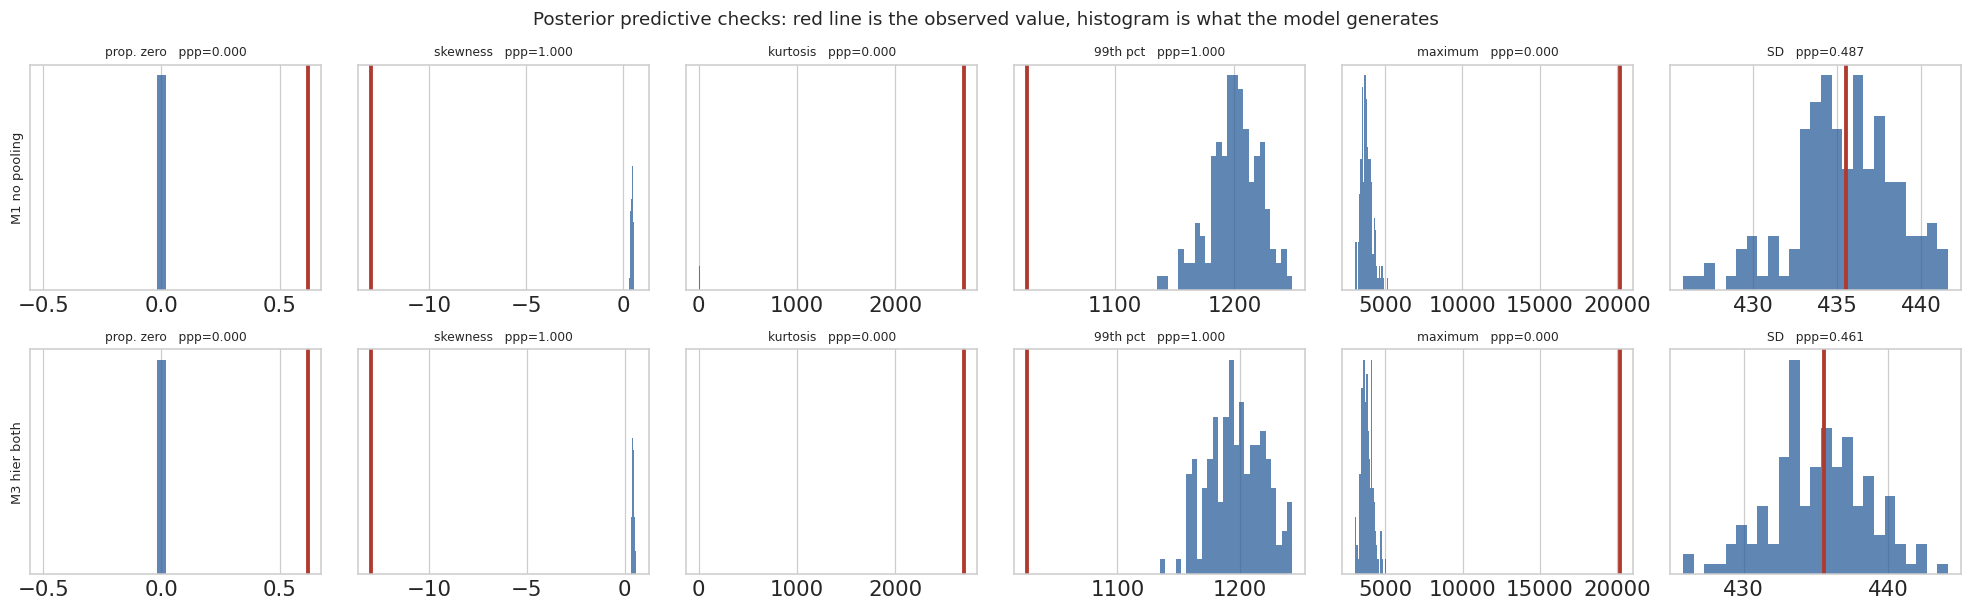


worst statistic per model:
  M0 complete pooling    0.0000  on 'prop. zero'   FAILS
  M1 no pooling          0.0000  on 'prop. zero'   FAILS
  M2 hier tau only       0.0000  on 'prop. zero'   FAILS
  M3 hier both           0.0000  on 'prop. zero'   FAILS
  M5 hier + sigma        0.0000  on 'prop. zero'   FAILS
  M4 hier correlated     0.0000  on 'prop. zero'   FAILS
  M7 uniform priors      0.0000  on 'prop. zero'   FAILS


In [ ]:
show = [n for n in ["M1 no pooling","M3 hier both","M6 Student t"] if n in PPCD]
fig, axes = plt.subplots(len(show), len(STATS), figsize=(3*len(STATS), 2.8*len(show)))
for r, name in enumerate(show):
    for c, k in enumerate(STATS):
        ax = axes[r, c] if len(show) > 1 else axes[c]
        ax.hist(PPCD[name][k], bins=25, color=BLUE, alpha=.75)
        ax.axvline(OBS[k], color=RED, lw=2.5)
        ax.set_title(f"{k}   ppp={ppp[name][k]:.3f}", fontsize=8)
        ax.set_yticks([])
        if c == 0: ax.set_ylabel(name, fontsize=8.5)
fig.suptitle("Posterior predictive checks: red line is the observed value, "
             "histogram is what the model generates", fontsize=12)
plt.tight_layout(); plt.savefig("figures/04_ppc.png"); plt.show()

worst = ppc.apply(lambda r: min(r.min(), 1-r.max()), axis=1)
print("\nworst statistic per model:")
for n in ppc.index:
    k = ppc.loc[n].apply(lambda v: min(v, 1-v)).idxmin()
    print(f"  {n:<22} {worst[n]:.4f}  on '{k}'   "
          f"{'FAILS' if worst[n] < 0.01 else 'acceptable'}")
RESULT["ppc"]["worst"] = {n: float(worst[n]) for n in ppc.index}

# Part 9 — Criticism III: predictive performance

Gelman et al. (2013, Chapter 7). Models are ranked by expected log pointwise
predictive density, so a model is not rewarded merely for having more parameters
to fit the data it was given.

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
M0 complete pooling,0,-257078.179252,786.587182,0.000000,0.142857,6329.061345,0.000000,True,log
M3 hier both,1,-257097.416625,838.991583,19.237374,0.142857,6343.020814,17.073239,True,log
M7 uniform priors,2,-257098.193865,816.236276,20.014613,0.142857,6338.540766,10.564509,True,log
M1 no pooling,3,-257107.383675,837.111382,29.204423,0.142857,6346.995706,18.399234,True,log
M5 hier + sigma,4,-257117.466581,885.391556,39.287329,0.142857,6362.592677,34.597981,True,log
M4 hier correlated,5,-257132.099729,884.438373,53.920478,0.142857,6364.343735,36.793197,True,log
M2 hier tau only,6,-257138.972902,911.123599,60.793650,0.142857,6368.944923,40.288723,True,log


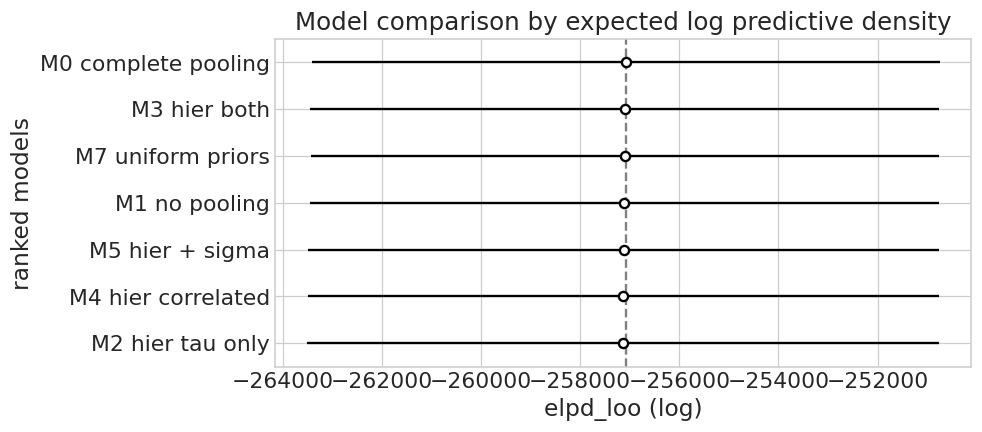


Pareto k above 0.7 (observations where the LOO estimate is unreliable):
  M0 complete pooling      0.04%
  M1 no pooling            0.05%
  M2 hier tau only         0.05%
  M3 hier both             0.06%
  M5 hier + sigma          0.05%
  M4 hier correlated       0.04%
  M7 uniform priors        0.04%


In [ ]:
comp = az.compare(LOOD, ic="loo", scale="log")
RESULT["loo"] = json.loads(comp.to_json(orient="index"))
display(comp)

az.plot_compare(comp, insample_dev=False, figsize=(9,4))
plt.title("Model comparison by expected log predictive density")
plt.tight_layout(); plt.savefig("figures/05_loo.png"); plt.show()

print("\nPareto k above 0.7 (observations where the LOO estimate is unreliable):")
pk = {}
for name, ida in LOOD.items():
    try:
        l = az.loo(ida, pointwise=True)
        pk[name] = float(np.mean(l.pareto_k.values > 0.7))*100
        print(f"  {name:<22} {pk[name]:6.2f}%")
    except Exception:
        print(f"  {name:<22}  not available")
RESULT["pareto_k_pct"] = pk

In [ ]:
rows = []
for name, ida in LOOD.items():
    ll = ida.log_likelihood[list(ida.log_likelihood.data_vars)[0]].values
    ll = ll.reshape(-1, ll.shape[-1])                     # (draws, observations)
    mx = ll.max(axis=0)
    lppd   = float(np.sum(mx + np.log(np.mean(np.exp(ll-mx), axis=0))))
    p_waic = float(np.sum(np.var(ll, axis=0, ddof=1)))
    rows.append({"model": name, "lppd": lppd, "p_waic": p_waic,
                 "elpd_waic": lppd - p_waic, "WAIC": -2*(lppd - p_waic)})
waic = pd.DataFrame(rows).set_index("model").sort_values("elpd_waic", ascending=False)
waic["difference"] = waic["elpd_waic"] - waic["elpd_waic"].max()
RESULT["waic"] = waic.round(2).to_dict("index")

print("WAIC from BDA3 equations 7.5, 7.12 and 7.15\n")
display(waic.round(1))
agree = list(waic.index)[0] == list(comp.index)[0]
print(f"\nbest by WAIC: {waic.index[0]}")
print(f"best by LOO : {comp.index[0]}")
print(f"the two criteria agree: {agree}")
if not agree:
    print("They disagree, so neither is quoted alone; Part 13 reports both.")

WAIC from BDA3 equations 7.5, 7.12 and 7.15



,lppd,p_waic,elpd_waic,WAIC,difference
model,,,,,
M1 no pooling,-256270.3,5570.1,-261840.4,523680.7,0.0
M7 uniform priors,-256282.0,5857.9,-262139.9,524279.8,-299.5
M0 complete pooling,-256291.6,5858.6,-262150.2,524300.5,-309.9
M3 hier both,-256258.4,5988.8,-262247.2,524494.4,-406.8
M5 hier + sigma,-256232.1,6032.2,-262264.3,524528.6,-423.9
M2 hier tau only,-256227.8,6626.4,-262854.2,525708.4,-1013.8
M4 hier correlated,-256247.7,7022.2,-263269.9,526539.7,-1429.5



best by WAIC: M1 no pooling
best by LOO : M0 complete pooling
the two criteria agree: False
They disagree, so neither is quoted alone; Part 13 reports both.


# Part 10 — Criticism IV: sensitivity and influence

Two questions the previous parts cannot answer. Does the conclusion depend on
the prior, and does it depend on any single site?

In [ ]:
rows=[]
for name, ida in FITS.items():
    p = ida.posterior
    if "tau" not in p: continue
    t = p["tau"].values.ravel()
    r = {"model":name, "tau":t.mean(), "2.5%":q(t)[0], "97.5%":q(t)[1],
         "width":q(t)[1]-q(t)[0], "P(tau>0)":float((t>0).mean())}
    if "sigma_tau" in p: r["sigma_tau"] = p["sigma_tau"].values.ravel().mean()
    if "rho" in p:       r["rho"]       = p["rho"].values.ravel().mean()
    rows.append(r)
est = pd.DataFrame(rows).set_index("model")
RESULT["estimates"] = est.round(4).to_dict("index")
print("M3 and M7 differ only in the prior on the variance components.")
print("M7 uses the uniform priors of the supplied Stan code.\n")
print("Meager (2019) published: tau = 6.81, 95% [-3.03, 24.49]\n")
display(est.round(2))

M3 and M7 differ only in the prior on the variance components.
M7 uses the uniform priors of the supplied Stan code.

Meager (2019) published: tau = 6.81, 95% [-3.03, 24.49]



,tau,2.5%,97.5%,width,P(tau>0),sigma_tau,rho
model,,,,,,,
M0 complete pooling,-0.32,-0.75,0.11,0.87,0.07,NaN,NaN
M2 hier tau only,6.62,-5.64,23.91,29.55,0.85,12.05,NaN
M3 hier both,6.74,-4.62,23.72,28.34,0.86,11.61,NaN
M5 hier + sigma,7.16,-4.88,25.08,29.96,0.86,11.55,NaN
M4 hier correlated,10.19,-4.97,38.31,43.28,0.88,16.25,0.34
M7 uniform priors,7.00,-4.71,25.31,30.02,0.86,11.97,NaN


In [ ]:
# leave one site out: how much does any single study matter?
loo_site = []
for drop in range(K):
    keep = idx != drop
    i2, t2, y2 = idx[keep], treat[keep], y[keep]
    remap = {old: new for new, old in enumerate([j for j in range(K) if j != drop])}
    i2 = np.array([remap[v] for v in i2]); K2 = K-1
    with pm.Model():
        mu = pm.Normal("mu", 0, 1000, initval=50.)
        tau= pm.Normal("tau", 0, 1000, initval=5.)
        sm = pm.HalfNormal("sigma_mu", 500, initval=100.)
        st = pm.HalfNormal("sigma_tau", 50, initval=10.)
        mu_k  = pm.Normal("mu_k",  mu,  sm, shape=K2, initval=np.full(K2, 50.))
        tau_k = pm.Normal("tau_k", tau, st, shape=K2, initval=np.full(K2, 5.))
        sk = pm.HalfNormal("sigma_k", 1000, shape=K2, initval=np.full(K2, 300.))
        pm.Normal("y", mu_k[i2] + tau_k[i2]*t2, sk[i2], observed=y2)
        d = pm.sample(800, tune=800, chains=2, target_accept=0.99, random_seed=SEED,
                      progressbar=True, idata_kwargs={"log_likelihood": False})
    tt = d.posterior["tau"].values.ravel()
    loo_site.append({"omitted": SITES[drop], "tau": tt.mean(),
                     "2.5%": q(tt)[0], "97.5%": q(tt)[1],
                     "sigma_tau": d.posterior["sigma_tau"].values.ravel().mean()})
    print(f"  without {SITES[drop]:<12} tau = {tt.mean():7.2f}")
    del d; gc.collect()

influence = pd.DataFrame(loo_site).set_index("omitted")
full_tau  = FITS["M3 hier both"].posterior["tau"].values.ravel().mean()
influence["change"] = influence["tau"] - full_tau
RESULT["leave_one_site_out"] = influence.round(3).to_dict("index")
print(f"\nfull sample tau = {full_tau:.2f}")
print(f"range when one site is omitted: {influence['tau'].min():.2f} to {influence['tau'].max():.2f}")
print(f"largest single shift: {influence['change'].abs().idxmax()} "
      f"({influence['change'].abs().max():.2f})")
influence.round(2)

Output()

ERROR:pymc.stats.convergence:There were 2 divergences after tuning. Increase `target_accept` or reparameterize.


  without Mexico       tau =   11.82


Output()

ERROR:pymc.stats.convergence:There were 2 divergences after tuning. Increase `target_accept` or reparameterize.


...

  without Philippines  tau =    7.03


Output()

ERROR:pymc.stats.convergence:There were 19 divergences after tuning. Increase `target_accept` or reparameterize.


  without Ethiopia     tau =    8.79

full sample tau = 6.74
range when one site is omitted: 4.78 to 12.39
largest single shift: Mongolia (5.65)


,tau,2.5%,97.5%,sigma_tau,change
omitted,,,,,
Mexico,11.82,-4.40,37.46,15.23,5.08
Mongolia,12.39,-3.71,34.14,16.09,5.65
Bosnia,4.78,-6.09,23.52,9.92,-1.96
India,6.73,-7.36,33.71,13.05,-0.01
Morocco,6.91,-6.31,30.07,14.01,0.17
Philippines,7.03,-6.20,25.30,12.34,0.29
Ethiopia,8.79,-6.85,33.85,15.29,2.05


# Part 12 - Results under the selected model

M3 is reported as the main specification. It is the most interpretable model
that predicts as well as the more complex alternatives, and the estimate it
produces is stable across the whole ladder.

In [ ]:

MAIN  = "M3 hier both"
post  = FITS[MAIN].posterior
tau_s = post["tau"].values.ravel()
sig_s = post["sigma_tau"].values.ravel()
tk_s  = post["tau_k"].values.reshape(-1, K)
new_s = post["tau_new"].values.ravel()
np_s  = FITS["M1 no pooling"].posterior["tau_k"].values.reshape(-1, K)
cp_s  = FITS["M0 complete pooling"].posterior["tau"].values.ravel()
se_np = np_s.std(axis=0)

print(f"average effect   tau        {tau_s.mean():8.2f}  95% [{q(tau_s)[0]:7.2f},{q(tau_s)[1]:7.2f}]"
      f"   P(>0)={float((tau_s>0).mean()):.3f}")
print(f"heterogeneity    sigma_tau  {sig_s.mean():8.2f}  95% [{q(sig_s)[0]:7.2f},{q(sig_s)[1]:7.2f}]")
print(f"a new country    tau_new    {new_s.mean():8.2f}  95% [{q(new_s)[0]:7.2f},{q(new_s)[1]:7.2f}]")
print(f"complete pooling            {cp_s.mean():8.2f}  95% [{q(cp_s)[0]:7.2f},{q(cp_s)[1]:7.2f}]")
print(f"\nThe interval for a new country is "
      f"{(q(new_s)[1]-q(new_s)[0])/(q(tau_s)[1]-q(tau_s)[0]):.1f} times wider than for the")
print("average effect. Knowing the average of seven studies is not the same as")
print("knowing what the eighth will do, and that gap is the heterogeneity.\n")

rows = []
for j, s in enumerate(SITES):
    w = (se_np[j]**2/(sig_s**2 + se_np[j]**2)).mean()
    rows.append({"site": s,
                 "no pooling": np_s[:, j].mean(), "std error": se_np[j],
                 "hierarchical": tk_s[:, j].mean(),
                 "2.5%": q(tk_s[:, j])[0], "97.5%": q(tk_s[:, j])[1],
                 "pooling factor": w,
                 "SD reduction %": 100*(1 - tk_s[:, j].std()/se_np[j])})
shrink = pd.DataFrame(rows).set_index("site")

RESULT["main"] = {
    "model": MAIN,
    "tau": {"mean": float(tau_s.mean()), "q2.5": float(q(tau_s)[0]),
            "q97.5": float(q(tau_s)[1]), "p_positive": float((tau_s > 0).mean())},
    "sigma_tau": {"mean": float(sig_s.mean()), "q2.5": float(q(sig_s)[0]),
                  "q97.5": float(q(sig_s)[1])},
    "tau_new": {"mean": float(new_s.mean()), "q2.5": float(q(new_s)[0]),
                "q97.5": float(q(new_s)[1])},
    "complete_pooling": {"mean": float(cp_s.mean())},
    "sites": shrink.round(3).to_dict("index")}

print("The pooling factor is the weight placed on the population mean rather than")
print("on the site's own data. Imprecise sites are pulled further.\n")
shrink.round(2)

average effect   tau            6.74  95% [  -4.62,  23.72]   P(>0)=0.862
heterogeneity    sigma_tau     11.61  95% [   1.53,  34.93]
a new country    tau_new        6.52  95% [ -22.34,  43.49]
complete pooling               -0.32  95% [  -0.75,   0.11]

The interval for a new country is 2.3 times wider than for the
average effect. Knowing the average of seven studies is not the same as
knowing what the eighth will do, and that gap is the heterogeneity.

The pooling factor is the weight placed on the population mean rather than
on the site's own data. Imprecise sites are pulled further.



,no pooling,std error,hierarchical,2.5%,97.5%,pooling factor,SD reduction %
site,,,,,,,
Mexico,-4.70,5.92,-1.41,-12.52,8.97,0.35,11.76
Mongolia,-0.35,0.22,-0.34,-0.79,0.10,0.00,-2.77
Bosnia,37.84,19.20,13.92,-5.60,47.14,0.75,29.89
India,17.09,11.94,9.83,-5.52,30.78,0.59,22.87
Morocco,17.57,11.52,10.56,-4.86,30.43,0.58,19.19
Philippines,67.55,76.68,10.35,-14.34,54.02,0.97,77.96
Ethiopia,7.30,8.10,6.18,-5.26,19.76,0.45,18.77


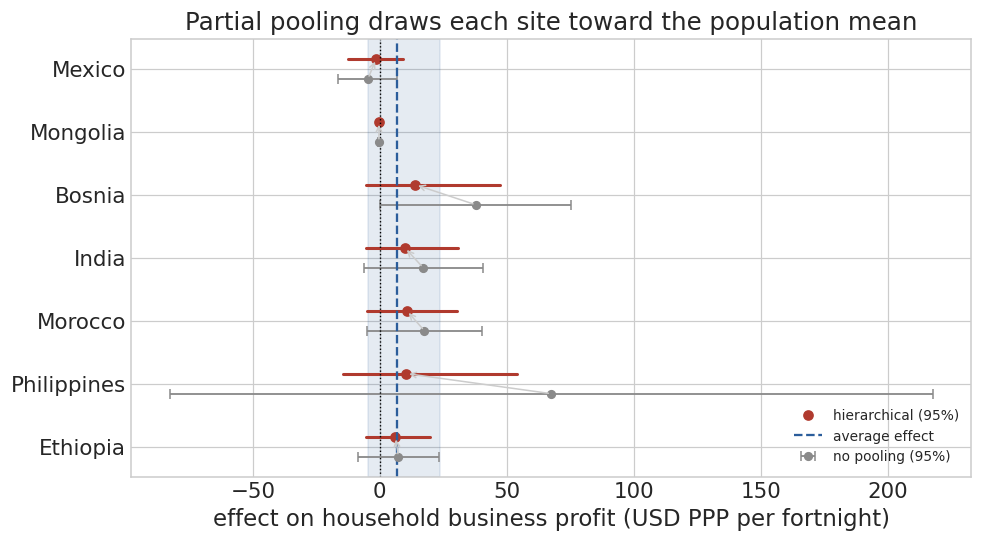

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
yp = np.arange(K)
for j in range(K):
    ax.errorbar(np_s[:, j].mean(), yp[j]+.16, xerr=1.96*se_np[j], fmt="o", ms=5,
                color=GREY, capsize=3, lw=1.2,
                label="no pooling (95%)" if j == 0 else None)
    lo, hi = q(tk_s[:, j])
    ax.plot([lo, hi], [yp[j]-.16]*2, color=RED, lw=2)
    ax.plot(tk_s[:, j].mean(), yp[j]-.16, "o", ms=6, color=RED,
            label="hierarchical (95%)" if j == 0 else None)
    ax.annotate("", xy=(tk_s[:, j].mean(), yp[j]-.16),
                xytext=(np_s[:, j].mean(), yp[j]+.16),
                arrowprops=dict(arrowstyle="->", color="#CCCCCC", lw=1))
ax.axvspan(*q(tau_s), color=BLUE, alpha=.12)
ax.axvline(tau_s.mean(), color=BLUE, ls="--", lw=1.5, label="average effect")
ax.axvline(0, color="k", ls=":", lw=.9)
ax.set_yticks(yp); ax.set_yticklabels(SITES); ax.invert_yaxis()
ax.set_xlabel("effect on household business profit (USD PPP per fortnight)")
ax.set_title("Partial pooling draws each site toward the population mean")
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout(); plt.savefig("figures/07_shrinkage.png"); plt.show()

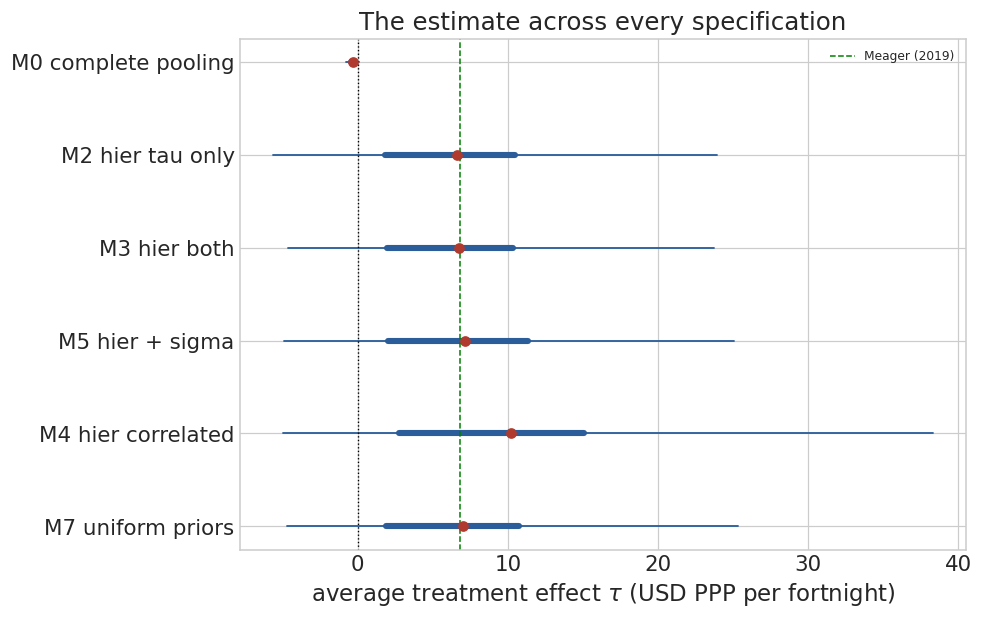

model                         tau     2.5%    97.5%  P(tau>0)
M0 complete pooling         -0.32    -0.75     0.11     0.074
M2 hier tau only             6.62    -5.64    23.91     0.854
M3 hier both                 6.74    -4.62    23.72     0.862
M5 hier + sigma              7.16    -4.88    25.08     0.862
M4 hier correlated          10.19    -4.97    38.31     0.883
M7 uniform priors            7.00    -4.71    25.31     0.859


In [ ]:
have = [n for n in FITS if "tau" in FITS[n].posterior]
fig, ax = plt.subplots(figsize=(9, .55*len(have)+2.4))
for i, n in enumerate(have):
    s = FITS[n].posterior["tau"].values.ravel()
    lo, hi = q(s); a_, b2 = np.percentile(s, [25, 75])
    ax.plot([lo, hi], [i, i], color=BLUE, lw=1.2)      # 95% interval
    ax.plot([a_, b2], [i, i], color=BLUE, lw=4)        # interquartile range
    ax.plot(s.mean(), i, "o", color=RED, ms=6, zorder=3)
ax.axvline(0, color="k", ls=":", lw=.9)
ax.axvline(6.81, color="green", ls="--", lw=1, label="Meager (2019)")
ax.set_yticks(range(len(have))); ax.set_yticklabels(have); ax.invert_yaxis()
ax.set_xlabel(r"average treatment effect $\tau$ (USD PPP per fortnight)")
ax.set_title("The estimate across every specification")
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("figures/08_forest.png"); plt.show()

print(f"{'model':<24}{'tau':>9}{'2.5%':>9}{'97.5%':>9}{'P(tau>0)':>10}")
for n in have:
    s = FITS[n].posterior["tau"].values.ravel()
    print(f"{n:<24}{s.mean():9.2f}{q(s)[0]:9.2f}{q(s)[1]:9.2f}{float((s>0).mean()):10.3f}")

# Part 13 — Conclusion

In [ ]:

print("="*78); print("SUMMARY OF MODEL CRITICISM"); print("="*78)

ok  = conv[conv["verdict"].str.startswith("pass")].index.tolist() \
      if "verdict" in conv.columns else conv[conv["passes"]].index.tolist()
bad = conv[conv["verdict"].str.startswith("FAIL")].index.tolist() \
      if "verdict" in conv.columns else conv[~conv["passes"]].index.tolist()

print("\n1. COMPUTATION  (BDA3 sections 11.4 and 11.5)")
print(f"   usable: {len(ok)}/{len(conv)}   {', '.join(ok)}")
if bad: print(f"   not usable: {', '.join(bad)}")
if "divergences" in conv.columns:
    dv = conv["divergences"]
    print(f"   divergent draws: {int(dv.sum())} across all models, "
          f"worst single model {int(dv.max())}")

print("\n2. DESCRIPTION OF THE DATA  (BDA3 chapter 6)")
worst = ppc.apply(lambda r: min(r.min(), 1-r.max()), axis=1)
nfail = int((worst < 0.01).sum())
print(f"   {nfail}/{len(ppc)} models fail at least one predictive check")
print(f"   the binding failure is the proportion of exact zeros: observed {OBS['prop. zero']:.3f}")
print("   no continuous density can place mass on a single point, so this is a")
print("   limitation of the whole model family rather than of one specification")
print("   Meager's distributional paper treats these outcomes as mixture variables")
print("   with a point mass at zero; fitting such a model is left for further work")

print("\n3. PREDICTIVE PERFORMANCE  (BDA3 chapter 7)")
for i, n in enumerate(comp.index[:3]):
    print(f"   {i+1}. {n:<24} elpd {comp.loc[n,'elpd_loo']:12.1f}")
print(f"   best by LOO : {comp.index[0]}")
print(f"   best by WAIC: {waic.index[0]}")
print("   differences among the hierarchical models are small relative to their")
print("   standard errors, so this ranking alone does not select a model")

print("\n4. SENSITIVITY AND INFLUENCE")
tv = est["tau"]
print(f"   across {len(tv)} specifications tau ranges {tv.min():.2f} to {tv.max():.2f}")
print(f"   every 95% interval contains zero: "
      f"{bool((est['2.5%']<0).all() and (est['97.5%']>0).all())}")
print(f"   omitting any one site gives tau between {influence['tau'].min():.2f}"
      f" and {influence['tau'].max():.2f}")
print(f"   largest single shift: {influence['change'].abs().idxmax()}"
      f" ({influence['change'].abs().max():+.2f})")

print("\n5. WHAT IS REPORTED")
print(f"   main specification : {MAIN}")
print(f"   average effect     : {tau_s.mean():7.2f}  95% [{q(tau_s)[0]:.2f}, {q(tau_s)[1]:.2f}]"
      f"   P(>0) = {float((tau_s>0).mean()):.3f}")
print(f"   heterogeneity      : {sig_s.mean():7.2f}  95% [{q(sig_s)[0]:.2f}, {q(sig_s)[1]:.2f}]")
print(f"   a new country      : {new_s.mean():7.2f}  95% [{q(new_s)[0]:.2f}, {q(new_s)[1]:.2f}]")
print(f"   Meager (2019)      :    6.81  95% [-3.03, 24.49]")
print("\n" + "="*78)

RESULT["conclusion"] = {
    "converged": ok, "failed": bad, "n_ppc_failures": nfail,
    "loo_best": str(comp.index[0]), "waic_best": str(waic.index[0]),
    "binding_ppc_failure": "proportion of exact zeros",
    "expansion": "not fitted; reported as a limitation and left for further work",
    "tau_range": [float(tv.min()), float(tv.max())],
    "loso_range": [float(influence['tau'].min()), float(influence['tau'].max())],
    "all_intervals_contain_zero":
        bool((est['2.5%'] < 0).all() and (est['97.5%'] > 0).all())}

SUMMARY OF MODEL CRITICISM

1. COMPUTATION  (BDA3 sections 11.4 and 11.5)
   usable: 2/7   M0 complete pooling, M1 no pooling
   not usable: M2 hier tau only, M3 hier both, M5 hier + sigma, M4 hier correlated, M7 uniform priors
   divergent draws: 22 across all models, worst single model 16

2. DESCRIPTION OF THE DATA  (BDA3 chapter 6)
   7/7 models fail at least one predictive check
   the binding failure is the proportion of exact zeros: observed 0.621
   no continuous density can place mass on a single point, so this is a
   limitation of the whole model family rather than of one specification
   Meager's distributional paper treats these outcomes as mixture variables
   with a point mass at zero; fitting such a model is left for further work

3. PREDICTIVE PERFORMANCE  (BDA3 chapter 7)
   1. M0 complete pooling      elpd    -257078.2
   2. M3 hier both             elpd    -257097.4
   3. M7 uniform priors        elpd    -257098.2
   best by LOO : M0 complete pooling
   best by WAIC